In [2]:
#“This dataset appears to contain sales order information including order quantity, price, sales amount, customer details, and location. I would start by performing exploratory data analysis by checking missing values, data types, and summary statistics. Then I would analyze sales trends by year, month, and quarter. I would also evaluate which countries, product lines, and customers generate the most revenue. Finally, I would visualize the results to identify patterns and provide business insights.”

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("../data/sales_data_sample.csv",encoding="latin1")

In [5]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [6]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [7]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,Motorcycles,95,S10_1678,Corporate Gift Ideas Co.,6505551386,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [8]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [9]:
df.isnull().mean()*100

ORDERNUMBER          0.000000
QUANTITYORDERED      0.000000
PRICEEACH            0.000000
ORDERLINENUMBER      0.000000
SALES                0.000000
ORDERDATE            0.000000
STATUS               0.000000
QTR_ID               0.000000
MONTH_ID             0.000000
YEAR_ID              0.000000
PRODUCTLINE          0.000000
MSRP                 0.000000
PRODUCTCODE          0.000000
CUSTOMERNAME         0.000000
PHONE                0.000000
ADDRESSLINE1         0.000000
ADDRESSLINE2        89.302161
CITY                 0.000000
STATE               52.639036
POSTALCODE           2.692171
COUNTRY              0.000000
TERRITORY           38.044633
CONTACTLASTNAME      0.000000
CONTACTFIRSTNAME     0.000000
DEALSIZE             0.000000
dtype: float64

In [10]:
import pandas as pd

# Example: load your data
# df = pd.read_csv("your_file.csv")

# 1️⃣ Address Line 2: fill missing with empty string or "N/A"
df['ADDRESSLINE2'] = df['ADDRESSLINE2'].fillna('')

# 2️⃣ State: try to fill from City or Zip if possible
# Suppose you have a mapping dictionary like: city_to_state
# city_to_state = {'Trivandrum': 'Kerala', 'Kochi': 'Kerala', ...}

# Mapping City → State
city_to_state = {
    'Trivandrum': 'Kerala',
    'Kochi': 'Kerala',
    'Chennai': 'Tamil Nadu'
}

# Mapping State → Territory
state_to_territory = {
    'Kerala': 'South',
    'Tamil Nadu': 'South'
}

if 'City' in df.columns:
    df['STATE'] = df.apply(
        lambda row: city_to_state[row['CITY']] if pd.isna(row['STATE']) and row['CITY'] in city_to_state else row['STATE'], 
        axis=1
    )

# Fill remaining missing States with "Unknown"
df['STATE'] = df['STATE'].fillna('Unknown')

# 3️⃣ Territory: fill based on State if possible
# Suppose you have a mapping dictionary: state_to_territory
# state_to_territory = {'Kerala': 'South', 'Tamil Nadu': 'South', ...}

df['TERRITORY'] = df.apply(
    lambda row: state_to_territory[row['STATE']] if pd.isna(row['TERRITORY']) and row['STATE'] in state_to_territory else row['TERRITORY'],
    axis=1
)

# Fill remaining missing Territories with "Unknown"
df['TERRITORY'] = df['TERRITORY'].fillna('Unknown')

# ✅ Check results
print(df[['ADDRESSLINE2']])

     ADDRESSLINE2
0                
1                
2                
3                
4                
...           ...
2818             
2819             
2820             
2821             
2822             

[2823 rows x 1 columns]


In [11]:
df.isnull().mean()*100

ORDERNUMBER         0.000000
QUANTITYORDERED     0.000000
PRICEEACH           0.000000
ORDERLINENUMBER     0.000000
SALES               0.000000
ORDERDATE           0.000000
STATUS              0.000000
QTR_ID              0.000000
MONTH_ID            0.000000
YEAR_ID             0.000000
PRODUCTLINE         0.000000
MSRP                0.000000
PRODUCTCODE         0.000000
CUSTOMERNAME        0.000000
PHONE               0.000000
ADDRESSLINE1        0.000000
ADDRESSLINE2        0.000000
CITY                0.000000
STATE               0.000000
POSTALCODE          2.692171
COUNTRY             0.000000
TERRITORY           0.000000
CONTACTLASTNAME     0.000000
CONTACTFIRSTNAME    0.000000
DEALSIZE            0.000000
dtype: float64

In [12]:
#sales by country
df.groupby('COUNTRY')['SALES'].sum()

COUNTRY
Australia       630623.10
Austria         202062.53
Belgium         108412.62
Canada          224078.56
Denmark         245637.15
Finland         329581.91
France         1110916.52
Germany         220472.09
Ireland          57756.43
Italy           374674.31
Japan           188167.81
Norway          307463.70
Philippines      94015.73
Singapore       288488.41
Spain          1215686.92
Sweden          210014.21
Switzerland     117713.56
UK              478880.46
USA            3627982.83
Name: SALES, dtype: float64

In [13]:
#sales by product line
df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)
prd_sales= df.groupby('PRODUCTLINE')['SALES'].sum()
prd_sales.nlargest(1)

PRODUCTLINE
Classic Cars    3919615.66
Name: SALES, dtype: float64

In [14]:
#monthly sales trend

customer_sales=df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=True)
customer_sales.nlargest(1)

CUSTOMERNAME
Euro Shopping Channel    912294.11
Name: SALES, dtype: float64

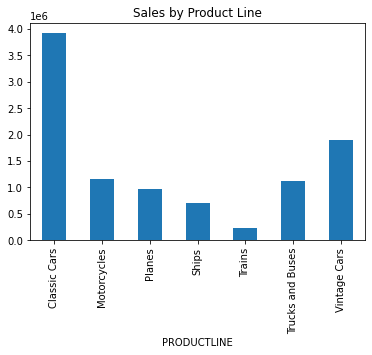

In [15]:
import matplotlib.pyplot as plt
df.groupby('PRODUCTLINE')['SALES'].sum().plot(kind='bar')
plt.title("Sales by Product Line")
plt.show()

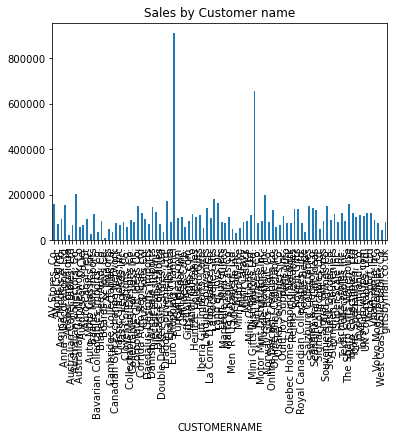

In [16]:
df.groupby('CUSTOMERNAME')['SALES'].sum().plot(kind='bar')
plt.title("Sales by Customer name")
plt.show()

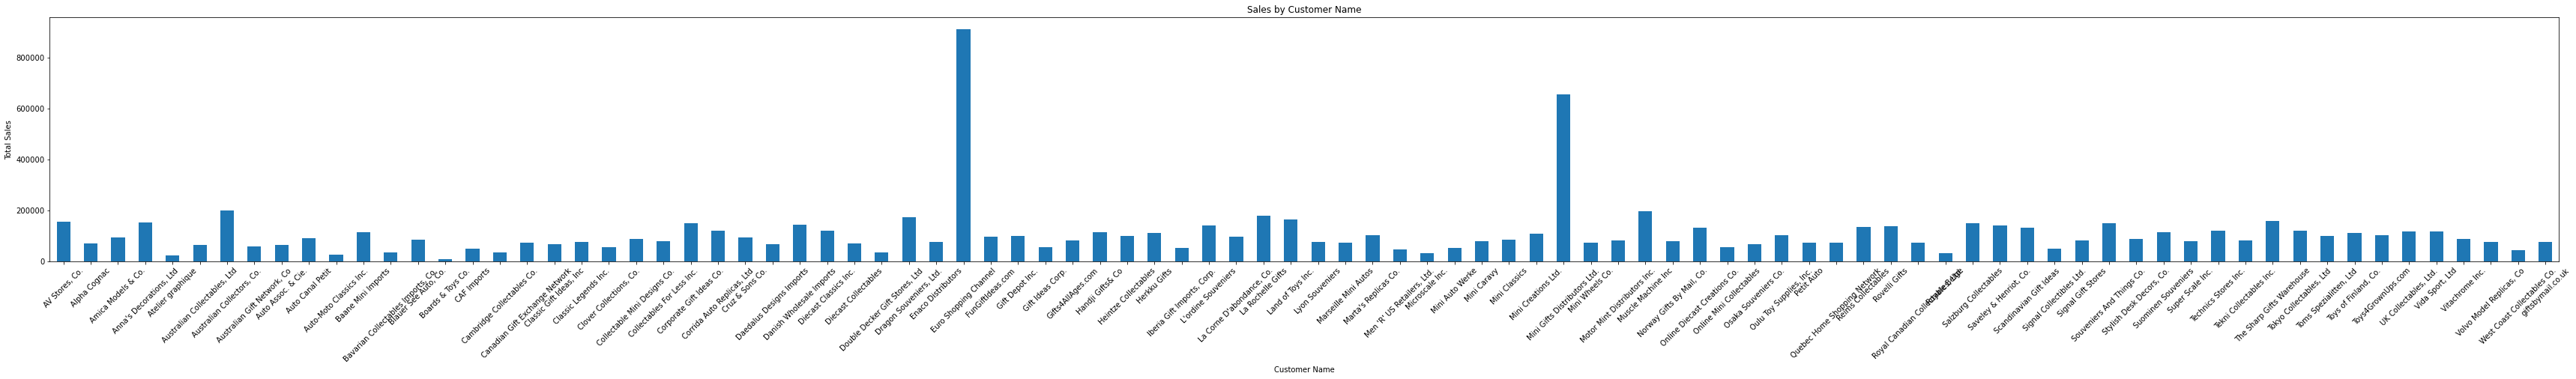

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(60, 6))  # width, height

df.groupby('CUSTOMERNAME')['SALES'].sum().plot(kind='bar')

plt.title("Sales by Customer Name")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.show()

In [18]:
#Machine Learning

features=['QUANTITYORDERED', 'PRICEEACH', 'PRODUCTLINE', 'COUNTRY', 'DEALSIZE']
target = 'SALES'

x=df[features]
y=df[target]

In [19]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
categorical=['PRODUCTLINE','COUNTRY', 'DEALSIZE']
numerical=['QUANTITYORDERED', 'PRICEEACH']

preprocessor= ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore'),categorical),
        ('num','passthrough',numerical)
    ]
)

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model= Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])

In [24]:
model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['PRODUCTLINE', 'COUNTRY',
                                                   'DEALSIZE']),
                                                 ('num', 'passthrough',
                                                  ['QUANTITYORDERED',
                                                   'PRICEEACH'])])),
                ('regressor', LinearRegression())])

In [25]:
y_pred=model.predict(x_test)

In [26]:
from sklearn.metrics import mean_absolute_error,r2_score
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("mae: ",mae)
print("r2 score:",r2)

mae:  493.523574056615
r2 score: 0.8717985406566642


In [27]:
#I built a regression model to predict sales using features like quantity, price, product line, and country. I used one-hot encoding for categorical variables and evaluated the model using MAE and R² score.

In [32]:
from sklearn.ensemble import RandomForestRegressor

model=Pipeline(steps=[('preprocessor',preprocessor),
                      ('regressor',RandomForestRegressor())
                     ])

In [33]:
model.fit(x_train,y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['PRODUCTLINE', 'COUNTRY',
                                                   'DEALSIZE']),
                                                 ('num', 'passthrough',
                                                  ['QUANTITYORDERED',
                                                   'PRICEEACH'])])),
                ('regressor', RandomForestRegressor())])

In [34]:
y_pred=model.predict(x_test)

In [35]:
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("mae: ",mae)
print("r2 score:",r2)

mae:  337.32684836821943
r2 score: 0.8954210691504896
